In [1]:
import os
import random
import cv2
from torch.nn import Module
from torch.nn import Conv2d
from torch.nn import Linear
from torch.nn import MaxPool2d
from torch.nn import ReLU
from torch.nn import LogSoftmax
from torch.utils.data import DataLoader
from torch import flatten
from torch import nn
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import copy
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive/')
os.chdir('/content/drive/MyDrive/vision/raw-img')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:



class CNN(Module):
	def __init__(self, numChannels, classes):
		super(CNN, self).__init__()
		self.conv1 = Conv2d(in_channels=numChannels, out_channels=16, kernel_size=(5, 5))
		self.relu1 = ReLU()
		self.maxpool1 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
		self.conv2 = Conv2d(in_channels=16, out_channels=32, kernel_size=(5, 5))
		self.relu2 = ReLU()
		self.maxpool2 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
		self.conv3 = Conv2d(in_channels=32, out_channels=64, kernel_size=(5, 5))
		self.relu3 = ReLU()
		self.maxpool3 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
		self.conv4 = Conv2d(in_channels=64, out_channels=128, kernel_size=(5, 5))
		self.relu4 = ReLU()
		self.maxpool4 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
		self.conv5 = Conv2d(in_channels=128, out_channels=256, kernel_size=(5, 5))
		self.relu5 = ReLU()
		self.conv6 = Conv2d(in_channels=256, out_channels=512, kernel_size=(5, 5))
		self.relu6 = ReLU()
		self.fc1 = Linear(in_features=25088, out_features=500)
		self.relu7 = ReLU()
		self.fc2 = Linear(in_features=500, out_features=classes)
		self.logSoftmax = LogSoftmax(dim=1)

		self.dropout = nn.Dropout(0.8)

	def forward(self, x):
		x = self.conv1(x)
		x = self.relu1(x)
		x = self.maxpool1(x)
		x = self.conv2(x)
		x = self.relu2(x)
		x = self.maxpool2(x)
		x = self.conv3(x)
		x = self.relu3(x)
		x = self.maxpool3(x)
		x = self.conv4(x)
		x = self.relu4(x)
		x = self.maxpool4(x)
		x = self.conv5(x)
		x = self.relu5(x)
		x = self.conv6(x)
		x = self.relu6(x)
		x = flatten(x, 1)
		x = self.fc1(x)
		x = self.relu7(x)
		x = self.dropout(x)
		x = self.fc2(x)
		output = self.logSoftmax(x)
		return output

def train(model,trainDataLoader,device,lossFn,opt,EPOCHS,validationDataLoader, early_stopping):
	trainSteps = len(trainDataLoader.dataset)
	valSteps = len(validationDataLoader.dataset)
	H = {
		"train_loss": [],
		"train_acc": [],
		"val_loss": [],
		"val_acc": []
	}

	best_loss = float('inf')
	best_model_weights = None
	patience = early_stopping
	for e in range(0, EPOCHS):
		# set the model in training mode
		model.train()
		# initialize the total training and validation loss
		totalTrainLoss = 0
		totalValLoss = 0
		# initialize the number of correct predictions in the training
		# and validation step
		trainCorrect = 0
		valCorrect = 0
		# loop over the training set

		for (x, y) in trainDataLoader:
			# send the input to the device
			(x, y) = (x.to(device), y.to(device))


			pred = model(x)
			loss = lossFn(pred, y)
			# zero out the gradients, perform the backpropagation step,
			# and update the weights
			opt.zero_grad()
			loss.backward()
			opt.step()
			# add the loss to the total training loss so far and
			# calculate the number of correct predictions
			totalTrainLoss += loss
			trainCorrect += (pred.argmax(1) == y).type(
				torch.float).sum().item()
			# switch off autograd for evaluation
		with torch.no_grad():
			# set the model in evaluation mode
			model.eval()
			# loop over the validation set
			for (x, y) in validationDataLoader:
				# send the input to the device
				(x, y) = (x.to(device), y.to(device))
				pred = model(x)
				totalValLoss += lossFn(pred, y)
				# calculate the number of correct predictions
				valCorrect += (pred.argmax(1) == y).type(
					torch.float).sum().item()

				# calculate the average training and validation loss
		avgTrainLoss = totalTrainLoss / trainSteps
		avgValLoss = totalValLoss / valSteps
		# calculate the training and validation accuracy
		trainCorrect = trainCorrect / len(trainDataLoader.dataset)
		valCorrect = valCorrect / len(validationDataLoader.dataset)
		# update our training history
		H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
		H["train_acc"].append(trainCorrect)
		H["val_loss"].append(avgValLoss.cpu().detach().numpy())
		H["val_acc"].append(valCorrect)
		# print the model training and validation information
		print("[INFO] EPOCH: {}/{}".format(e + 1, EPOCHS))
		print("Train loss: {:.6f}, Train accuracy: {:.4f}".format(
			avgTrainLoss, trainCorrect))
		print("Val loss: {:.6f}, Val accuracy: {:.4f}\n".format(
			avgValLoss, valCorrect))
		if avgValLoss < best_loss:
			best_loss = avgValLoss
			best_model_weights = copy.deepcopy(model.state_dict())  # Deep copy here
			patience = early_stopping  # Reset patience counter
		else:
			patience -= 1
			if patience == 0:
				break
	model.load_state_dict(best_model_weights)

	return H

def test(model, testDataLoader, device):
	# set the model in evaluation mode
	model.eval()
	# initialize the list of predictions
	preds = []
	# loop over the test set
	for x,y in testDataLoader:
		# send the input to the device
		x = x.to(device)
		pred = model(x)
		preds.extend(pred.argmax(1).cpu().numpy())
	# return the predictions
	return preds

def report(preds, testDataLoader):
	a=0
	true_ones = 0
	total = 0
	# loop over the test set
	for (x, y) in testDataLoader:
		true_ones += (preds[a*32:a*32+32] == y.numpy()).sum()
		total += len(y)
		a+=1
	print("Accuracy: {:.4f}".format(true_ones / total))


In [4]:
dataset_folder = '/content/drive/MyDrive/vision/raw-img'
#read folders inside dataset_folder and get the names of the folders
classes = os.listdir(dataset_folder)
# read data class by class and store it in a list
data = []
limit = 0
for i, c in enumerate(classes):
    files = os.listdir(os.path.join(dataset_folder, c))
    a=0
    for f in files:
        if limit == 0:
            data_image = cv2.imread(os.path.join(dataset_folder,c, f))
            data.append((data_image, i))
        else :
            a+=1
            if a <= limit:
                data_image = cv2.imread(os.path.join(dataset_folder,c, f))
                data.append((data_image, i))
print(len(data))
random.shuffle(data)
train_split = 0.7
val_split = 0.10
test_split = 0.20
train_data = data[:int(len(data)*train_split)]
val_data = data[int(len(data)*train_split):int(len(data)*(train_split+val_split))]
test_data = data[int(len(data)*(train_split+val_split)):]

batch_size = 32

train_data = [(cv2.resize(x, (300, 300)), y) for x, y in train_data]
val_data = [(cv2.resize(x, (300, 300)), y) for x, y in val_data]
test_data = [(cv2.resize(x, (300, 300)), y) for x, y in test_data]

#use transform.ToTensor to convert the image to tensor
transform = transforms.Compose([transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
train_data = [(transform(x), y) for x, y in train_data]
val_data = [(transform(x), y) for x, y in val_data]
test_data = [(transform(x), y) for x, y in test_data]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)











26179


In [5]:
model = CNN(3, len(classes))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.0004, momentum=0.9)
early_stopping  = 5
criterion = nn.CrossEntropyLoss()

In [6]:
train(model, train_loader, device, criterion, optimizer, 100, val_loader,early_stopping)

[INFO] EPOCH: 1/100
Train loss: 0.071164, Train accuracy: 0.1721
Val loss: 0.070049, Val accuracy: 0.1818

[INFO] EPOCH: 2/100
Train loss: 0.069419, Train accuracy: 0.1819
Val loss: 0.069070, Val accuracy: 0.1818

[INFO] EPOCH: 3/100
Train loss: 0.069195, Train accuracy: 0.1830
Val loss: 0.068972, Val accuracy: 0.1818

[INFO] EPOCH: 4/100
Train loss: 0.069092, Train accuracy: 0.1842
Val loss: 0.068861, Val accuracy: 0.1818

[INFO] EPOCH: 5/100
Train loss: 0.068781, Train accuracy: 0.1954
Val loss: 0.067977, Val accuracy: 0.2212

[INFO] EPOCH: 6/100
Train loss: 0.067305, Train accuracy: 0.2212
Val loss: 0.065972, Val accuracy: 0.2410

[INFO] EPOCH: 7/100
Train loss: 0.065822, Train accuracy: 0.2521
Val loss: 0.064087, Val accuracy: 0.2865

[INFO] EPOCH: 8/100
Train loss: 0.063192, Train accuracy: 0.2918
Val loss: 0.060830, Val accuracy: 0.3312

[INFO] EPOCH: 9/100
Train loss: 0.061292, Train accuracy: 0.3147
Val loss: 0.059291, Val accuracy: 0.3461

[INFO] EPOCH: 10/100
Train loss: 0.06

{'train_loss': [array(0.07116439, dtype=float32),
  array(0.06941853, dtype=float32),
  array(0.06919483, dtype=float32),
  array(0.06909218, dtype=float32),
  array(0.06878083, dtype=float32),
  array(0.06730545, dtype=float32),
  array(0.06582201, dtype=float32),
  array(0.06319188, dtype=float32),
  array(0.06129195, dtype=float32),
  array(0.06005311, dtype=float32),
  array(0.05911591, dtype=float32),
  array(0.05794429, dtype=float32),
  array(0.05708593, dtype=float32),
  array(0.05597949, dtype=float32),
  array(0.05515369, dtype=float32),
  array(0.05426786, dtype=float32),
  array(0.0533751, dtype=float32),
  array(0.0524024, dtype=float32),
  array(0.05149382, dtype=float32),
  array(0.05036044, dtype=float32),
  array(0.04944379, dtype=float32),
  array(0.04840164, dtype=float32),
  array(0.0473418, dtype=float32),
  array(0.04634585, dtype=float32),
  array(0.04517865, dtype=float32),
  array(0.04415246, dtype=float32),
  array(0.04270459, dtype=float32),
  array(0.0418142

In [7]:
preds = test(model, test_loader, device)

In [9]:
def confusion_matrix(preds, testDataLoader):
	# initialize the confusion matrix
	cm = np.zeros((10, 10), dtype="int")
	total = 0
	trues = 0
	# loop over the test set
	for (x, y) in testDataLoader:
		# loop over the true class labels and the predicted
		# class labels
		for (true, pred) in zip(y.numpy(), preds[total:total + 32]):
			# update the confusion matrix
			cm[true][pred] += 1
			# update the total number of correct predictions
			if true == pred:
				trues += 1
		total += len(y)
	# return the confusion matrix
	print("Accuracy: {:.4f}".format(trues / total))
	return cm

def plot_confusion_matrix(cm):
	# plot the confusion matrix
	plt.figure()
	plt.imshow(cm, interpolation="nearest")
	plt.title("Confusion Matrix")
	plt.colorbar()
	tick_marks = np.arange(10)
	plt.xticks(tick_marks, range(10))
	plt.yticks(tick_marks, range(10))
	plt.xlabel("Predicted Label")
	plt.ylabel("True Label")
	plt.show()

Accuracy: 0.9723


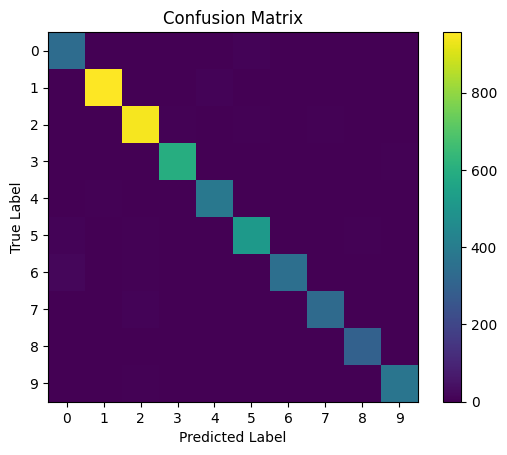

In [10]:
cm = confusion_matrix(preds,test_loader)
plot_confusion_matrix(cm)

In [10]:
report(preds, test_loader)

NameError: name 'H' is not defined

In [6]:

model = torchvision.models.efficientnet_b0(pretrained=True)
for param in model.parameters():
    param.requires_grad_(False)
model.classifier[1] = nn.Linear(1280, len(classes))
for param in model.classifier[1].parameters():
    param.requires_grad_(True)
for param in model.features[6].parameters():
    param.requires_grad_(True)
for param in model.features[7].parameters():
    param.requires_grad_(True)

model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0004, momentum=0.9)
criterion = nn.CrossEntropyLoss()
early_stopping = 5
train(model, train_loader, device, criterion, optimizer, 100, val_loader, early_stopping)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]


[INFO] EPOCH: 1/100
Train loss: 0.040231, Train accuracy: 0.6992
Val loss: 0.016694, Val accuracy: 0.9118

[INFO] EPOCH: 2/100
Train loss: 0.013749, Train accuracy: 0.9039
Val loss: 0.008351, Val accuracy: 0.9404

[INFO] EPOCH: 3/100
Train loss: 0.009189, Train accuracy: 0.9249
Val loss: 0.006157, Val accuracy: 0.9530

[INFO] EPOCH: 4/100
Train loss: 0.007459, Train accuracy: 0.9357
Val loss: 0.005147, Val accuracy: 0.9576

[INFO] EPOCH: 5/100
Train loss: 0.006472, Train accuracy: 0.9429
Val loss: 0.004581, Val accuracy: 0.9610

[INFO] EPOCH: 6/100
Train loss: 0.005635, Train accuracy: 0.9497
Val loss: 0.004213, Val accuracy: 0.9633

[INFO] EPOCH: 7/100
Train loss: 0.005118, Train accuracy: 0.9544
Val loss: 0.003898, Val accuracy: 0.9652

[INFO] EPOCH: 8/100
Train loss: 0.004690, Train accuracy: 0.9568
Val loss: 0.003704, Val accuracy: 0.9672

[INFO] EPOCH: 9/100
Train loss: 0.004264, Train accuracy: 0.9622
Val loss: 0.003525, Val accuracy: 0.9691

[INFO] EPOCH: 10/100
Train loss: 0.00

{'train_loss': [array(0.04023081, dtype=float32),
  array(0.01374858, dtype=float32),
  array(0.00918871, dtype=float32),
  array(0.00745906, dtype=float32),
  array(0.00647159, dtype=float32),
  array(0.00563475, dtype=float32),
  array(0.00511828, dtype=float32),
  array(0.00469029, dtype=float32),
  array(0.00426357, dtype=float32),
  array(0.0039351, dtype=float32),
  array(0.0035817, dtype=float32),
  array(0.00337641, dtype=float32),
  array(0.00309611, dtype=float32),
  array(0.00297204, dtype=float32),
  array(0.00268871, dtype=float32),
  array(0.00252841, dtype=float32),
  array(0.00225126, dtype=float32),
  array(0.00222453, dtype=float32),
  array(0.00208714, dtype=float32),
  array(0.002027, dtype=float32),
  array(0.00185077, dtype=float32),
  array(0.00178017, dtype=float32),
  array(0.00165337, dtype=float32),
  array(0.00160415, dtype=float32),
  array(0.00146253, dtype=float32),
  array(0.00140295, dtype=float32),
  array(0.00136403, dtype=float32),
  array(0.00127546

In [7]:
preds = test(model, test_loader, device)
report(preds, test_loader)

Accuracy: 0.9723


In [19]:
print(model.features[6])

Sequential(
  (0): MBConv(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(112, 672, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(672, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Conv2dNormActivation(
        (0): Conv2d(672, 672, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), groups=672, bias=False)
        (1): BatchNorm2d(672, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (2): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(672, 28, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(28, 672, kernel_size=(1, 1), stride=(1, 1))
        (activation): SiLU(inplace=True)
        (scale_activation): Sigmoid()
      )
      (3): Conv2dNormActivation(
        (0): Conv2d(672, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNor

In [ ]:



train_loss = [0.07116439,
  0.06941853,
  0.06919483,
  0.06909218,
  0.06878083,
  0.06730545,
  0.06582201,
  0.06319188,
  0.06129195,
  0.06005311,
  0.05911591,
  0.05794429,
  0.05708593,
  0.05597949,
  0.05515369,
  0.05426786,
  0.0533751,
  0.0524024,
  0.05149382,
  0.05036044,
  0.04944379,
  0.04840164,
  0.0473418,
  0.04634585,
  0.04517865,
  0.04415246,
  0.04270459,
  0.04181421,
  0.04055862,
  0.03964511,
  0.03826677,
  0.03698315,
  0.03562482,
  0.03445493,
  0.03294612,
  0.0314969,
  0.03039909,
  0.02903103,
  0.02753728,
  0.02636026,
  0.02502789,
  0.02374066]

train_acc = [0.17211459754433833,
  0.18193724420190996,
  0.18297407912687585,
  0.18422919508867666,
  0.19536152796725784,
  0.22117326057298772,
  0.25211459754433835,
  0.29178717598908593,
  0.31470668485675307,
  0.32638472032742155,
  0.33648021828103686,
  0.34761255115961803,
  0.35656207366984993,
  0.373806275579809,
  0.3853206002728513,
  0.3989631650750341,
  0.4099863574351978,
  0.4197544338335607,
  0.4311050477489768,
  0.4454024556616644,
  0.4548431105047749,
  0.4679399727148704,
  0.4826193724420191,
  0.4976807639836289,
  0.5094133697135061,
  0.5180900409276944,
  0.534406548431105,
  0.5437380627557981,
  0.5591268758526603,
  0.5674215552523875,
  0.5813915416098226,
  0.5984720327421555,
  0.6137517053206003,
  0.6227557980900409,
  0.6392905866302865,
  0.6522783083219645,
  0.6693042291950887,
  0.6792905866302865,
  0.6952796725784447,
  0.70537517053206,
  0.7185266030013643,
  0.7324965893587995]

val_loss = [0.07004935,
  0.06907023,
  0.06897168,
  0.06886109,
  0.06797657,
  0.06597219,
  0.06408738,
  0.06083033,
  0.05929107,
  0.05802952,
  0.05701296,
  0.05566912,
  0.05487131,
  0.05377001,
  0.05313298,
  0.0522178,
  0.05131597,
  0.05032371,
  0.04948726,
  0.04887939,
  0.04754543,
  0.04704941,
  0.04687262,
  0.04562305,
  0.04497073,
  0.04391107,
  0.04343374,
  0.04268815,
  0.04183592,
  0.04219253,
  0.04121377,
  0.0396959,
  0.0406626,
  0.03943555,
  0.03965036,
  0.04034866,
  0.03931158,
  0.03960158,
  0.03957474,
  0.04076004,
  0.04004232,
  0.04023216]

val_acc = [0.18181818181818182,
  0.18181818181818182,
  0.18181818181818182,
  0.18181818181818182,
  0.22116119174942706,
  0.2410236822001528,
  0.28647822765469827,
  0.33116883116883117,
  0.3460656990068755,
  0.35943468296409475,
  0.37089381207028266,
  0.38617265087853325,
  0.39686783804430864,
  0.3995416348357525,
  0.4102368220015279,
  0.420550038197097,
  0.42895339954163486,
  0.44270435446906037,
  0.45569136745607336,
  0.4572192513368984,
  0.4744079449961803,
  0.4766997708174179,
  0.4744079449961803,
  0.49236058059587473,
  0.5034377387318564,
  0.5179526355996944,
  0.5190985485103132,
  0.529029793735676,
  0.5351413292589763,
  0.5378151260504201,
  0.5557677616501145,
  0.5752482811306341,
  0.5599694423223835,
  0.5733384262796027,
  0.5817417876241405,
  0.5729564553093965,
  0.5977845683728037,
  0.5821237585943468,
  0.5905271199388846,
  0.5802139037433155,
  0.599694423223835,
  0.5951107715813598]

In [ ]:
def graph_loss_accuracy(train_loss, train_acc, val_loss, val_acc):
	# plot the training loss and accuracy
	plt.style.use("ggplot")
	plt.figure()
 #use all data with scatter
	plt.plot(train_loss, label="train_loss")
	plt.plot(train_acc, label="train_acc")
	plt.plot(val_loss, label="val_loss")
	plt.plot(val_acc, label="val_acc")
	plt.title("Training Loss and Accuracy")
	plt.xlabel("Epoch #")
	plt.ylabel("Loss/Accuracy")
	plt.legend()
	plt.show()

In [ ]:
graph_loss_accuracy(train_loss, train_acc, val_loss, val_acc)